# Day-Ahead-Strompreis DE/LU — Modellierung & Backtest

Nach der [EDA](03_price_eda.ipynb) folgt hier die **Modellierungs-Story**: von den Baselines
über die leckagefreien Gate-Closure-Features zum **rolling-origin-Backtest** und der ehrlichen
Fehleranalyse. Kein Tuning-Zirkus — der Punkt ist **sichtbare DS-Sauberkeit**: erst der
Vergleichsmaßstab, dann das Modell, immer *relativ zur Baseline* berichtet.

> **Prognose-Rahmen.** Die Day-Ahead-Auktion fixiert alle 24 Preise des Tages D **gemeinsam**
> zum **Gate Closure (12:00 am Vortag D-1)**. Jedes Feature muss zu diesem Zeitpunkt bekannt
> sein — das ist die zentrale Leakage-Bedingung, die den ganzen Feature-Bau bestimmt.

**Ergebnis vorweg:** LightGBM erreicht **MAE 21,4 €/MWh** gegen **45,2** der Seasonal-Naive-Baseline
— **−52,8 %**, und schlägt die Baseline in *jedem* Jahr des Backtests.

In [1]:
import sys; sys.path.insert(0, "..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from src import config, features, model, evaluate

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.titleweight": "bold", "figure.dpi": 110})

# Farbschema: Modell grün (= gut), Baselines warm, Wahrheit anthrazit.
C_TRUTH, C_LGBM, C_NAIVE, C_SEAS = "#22303f", "#27ae60", "#e67e22", "#e74c3c"

df = pd.read_parquet(config.DATASET_PARQUET)

# Backtest-Artefakte: gecacht laden (der rolling-origin-Lauf ist teuer), sonst neu rechnen.
# So bleibt das Notebook aus einem frischen Clone reproduzierbar.
cache = config.PROCESSED / "price_backtest_results.parquet"
if cache.exists():
    preds = pd.read_parquet(cache)
    metrics = pd.read_csv(config.PROCESSED / "price_backtest_metrics.csv")
    regime = pd.read_csv(config.PROCESSED / "price_backtest_regime.csv")
    print("Backtest-Artefakte aus data/processed/ geladen (Cache).")
else:
    metrics, preds, regime, _ = evaluate.backtest_price(df)
    print("Backtest frisch gerechnet und gecacht.")

print(f"Backtest-Zeitraum: {preds.index.min():%Y-%m-%d} … {preds.index.max():%Y-%m-%d}"
      f"   |   {len(preds):,} bewertete Lieferstunden")

Backtest-Artefakte aus data/processed/ geladen (Cache).
Backtest-Zeitraum: 2022-01-08 … 2026-06-16   |   38,880 bewertete Lieferstunden


## 1 · Baselines zuerst — der ehrliche Maßstab

Ein Modell ohne Baseline sagt nichts. Für den Day-Ahead-Preis sind die naheliegenden trivialen
Prognosen zugleich **leckagefrei**, weil sie auf bereits geräumte Vortage zurückgreifen:

- **Naiv (Persistenz):** Preis von *gestern, gleiche Stunde* — Versatz 24 h (Tag D-1, längst
  auktioniert).
- **Seasonal-Naiv:** Preis von *letzter Woche, gleiche Stunde* — Versatz 168 h. Fängt den
  Wochenrhythmus (Werktag/Wochenende) ein und ist bei Strompreisen der **härtere** Maßstab.

Jedes gelernte Modell wird an genau diesen beiden gemessen. Eine Beispielwoche zeigt, was die
Baselines leisten — und wo sie an Regime-/Niveauwechseln scheitern.

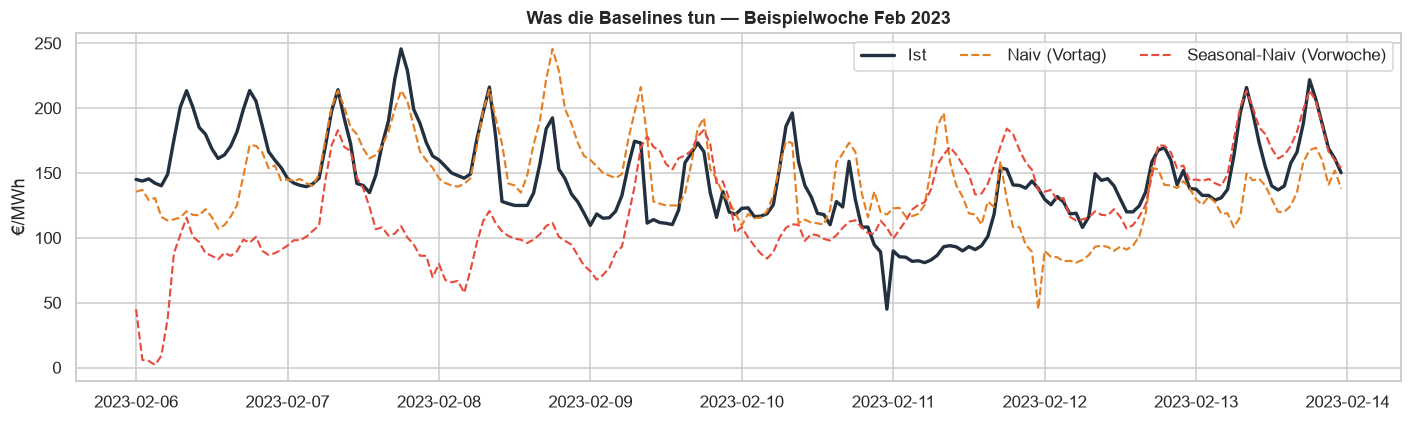

In [2]:
price = df[config.PRICE_TARGET]
naive_full = price.shift(24)
seas_full = price.shift(168)

wk = slice("2023-02-06", "2023-02-13")  # eine unaufgeregte Winterwoche
w_idx = price.loc[wk].index.tz_localize(None)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(w_idx, price.loc[wk].values, color=C_TRUTH, lw=2.2, label="Ist")
ax.plot(w_idx, naive_full.loc[wk].values, color=C_NAIVE, lw=1.4, ls="--", label="Naiv (Vortag)")
ax.plot(w_idx, seas_full.loc[wk].values, color=C_SEAS, lw=1.4, ls="--", label="Seasonal-Naiv (Vorwoche)")
ax.set(title="Was die Baselines tun — Beispielwoche Feb 2023", ylabel="€/MWh", xlabel="")
ax.legend(ncol=3, loc="upper right")
plt.tight_layout(); plt.show()

## 2 · Die Gate-Closure-Features — leckagefrei by construction

`features.make_supervised_dayahead` baut die Designmatrix, indiziert nach **Lieferstunde τ** auf
Tag D. Drei Feature-Gruppen, jede mit einem sauberen Bekanntheits-Argument zum Gate Closure:

1. **Fundamental-Prognosen zu τ** (`resload_fc_MW`, `load_fc_MW`, `wind_fc_MW`, `pv_fc_MW`) —
   SMARDs *eigene* Day-Ahead-Prognosen, am Morgen des Vortags **vor** 12:00 veröffentlicht. Genau
   deshalb dürfen wir ihren Wert *zur Lieferstunde* nehmen (Prognose, nicht Ist).
2. **Preishistorie ≤ D-1** — Same-Hour-Lags (D-1/D-2/D-7) plus Aggregate der *ganzen Vortagskurve*
   (Mittel/Min/Max/Std) und ein 7-Tage-Rollmittel. Alle um **volle Tage** verschoben, sodass Tag D
   nie hineinreicht. Sie kodieren das **Brennstoffkosten-/Regime-Niveau** (bewusster Gas-/CO₂-Proxy).
3. **Kalender von τ** (Stunde, Wochentag, Monat, Feiertag + zyklische Sin/Cos) — deterministisch.

Dass hier nichts aus dem Intervall (Gate Closure, τ] hineinleckt, ist **getestet**: der
Sentinel-Test in `tests/test_pipeline.py` (7/7 grün) setzt Tag D auf Unsinn und prüft, dass sich
keine Spalte ändert — plus eine Positivkontrolle, die echtes Leakage sicher *fängt*.

In [3]:
X, y = features.make_supervised_dayahead(df)

groups = {
    "Fundamental (Prognose)": ["resload_fc_MW", "load_fc_MW", "wind_fc_MW", "pv_fc_MW"],
    "Preishistorie (≤ D-1)": ["price_lag_24", "price_lag_48", "price_lag_168", "price_d1_mean",
                               "price_d1_min", "price_d1_max", "price_d1_std", "price_roll7_mean"],
    "Kalender (τ)": ["hour", "dayofweek", "month", "is_weekend", "is_holiday",
                     "hour_sin", "hour_cos", "dow_sin", "dow_cos"],
}
print(f"Designmatrix X: {X.shape[0]:,} Zeilen × {X.shape[1]} Features"
      f"   ({X.index.min():%Y-%m-%d} … {X.index.max():%Y-%m-%d})\n")
for name, cols in groups.items():
    print(f"  {name:24s} ({len(cols)}): {', '.join(cols)}")

display(X.head(3))

Designmatrix X: 48,215 Zeilen × 21 Features   (2021-01-08 … 2026-07-09)

  Fundamental (Prognose)   (4): resload_fc_MW, load_fc_MW, wind_fc_MW, pv_fc_MW
  Preishistorie (≤ D-1)    (8): price_lag_24, price_lag_48, price_lag_168, price_d1_mean, price_d1_min, price_d1_max, price_d1_std, price_roll7_mean
  Kalender (τ)             (9): hour, dayofweek, month, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos


,resload_fc_MW,load_fc_MW,wind_fc_MW,pv_fc_MW,price_lag_24,price_lag_48,price_lag_168,price_d1_mean,price_d1_min,price_d1_max,...,price_roll7_mean,hour,dayofweek,month,is_weekend,is_holiday,hour_sin,hour_cos,dow_sin,dow_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00+01:00,40774.75,48253.25,7478.50,0.0,51.03,44.41,50.87,70.927083,46.72,100.0,...,52.078333,0,4,1,0,0,0.000000,1.000000,-0.433884,-0.900969
2021-01-08 01:00:00+01:00,38840.50,46315.75,7475.25,0.0,50.18,42.94,48.19,70.927083,46.72,100.0,...,52.078333,1,4,1,0,0,0.258819,0.965926,-0.433884,-0.900969
2021-01-08 02:00:00+01:00,38244.50,45664.25,7419.75,0.0,48.97,42.88,44.68,70.927083,46.72,100.0,...,52.078333,2,4,1,0,0,0.500000,0.866025,-0.433884,-0.900969


## 3 · Rolling-Origin-Backtest — trainiere auf der Vergangenheit, teste auf der Zukunft

Ein Zufalls-Split wäre bei Zeitreihen **Leakage**: er ließe das Modell aus der Zukunft lernen.
Stattdessen ein **rolling-origin**-Schema (`evaluate.backtest_price`):

- **Rollierendes 2-Jahres-Trainingsfenster** — begrenzt Kosten und lässt das Modell dem
  Regimewechsel (Gaskrise) *folgen*, statt es mit altem Niveau zu verwässern.
- **Monatlich neu trainieren**, dann den **nächsten Monat** prognostizieren — so wie ein echter
  Forecaster das Modell periodisch nachzieht.
- Train- und Testblock überlappen **nie** in der Zeit; die Baselines werden auf **denselben**
  Ziel-Zeitstempeln bewertet.

Das erzeugt echte Out-of-Sample-Prognosen über gut vier Jahre — inklusive der Krisen.

In [4]:
splits = list(evaluate.rolling_origin_splits(
    X.index, config.INITIAL_TRAIN_HOURS, config.BACKTEST_STEP_HOURS,
    config.BACKTEST_STEP_HOURS, config.TRAIN_WINDOW_HOURS))

first_tr, first_te = splits[0]
last_tr, last_te = splits[-1]
print(f"Folds:                 {len(splits)}  (monatlicher Schritt)")
print(f"Trainingsfenster:      {config.TRAIN_WINDOW_HOURS // 24 // 365} Jahre rollierend "
      f"(max. {config.TRAIN_WINDOW_HOURS:,} h)")
print(f"Erster  Test-Block:    {first_te.min():%Y-%m-%d} … {first_te.max():%Y-%m-%d}"
      f"   (Training bis {first_tr.max():%Y-%m-%d})")
print(f"Letzter Test-Block:    {last_te.min():%Y-%m-%d} … {last_te.max():%Y-%m-%d}"
      f"   (Training ab {last_tr.min():%Y-%m-%d})")

Folds:                 54  (monatlicher Schritt)
Trainingsfenster:      2 Jahre rollierend (max. 17,520 h)
Erster  Test-Block:    2022-01-08 … 2022-02-06   (Training bis 2022-01-07)
Letzter Test-Block:    2026-05-17 … 2026-06-16   (Training ab 2024-05-17)


## 4 · Ergebnis gegen die Baselines

Die Kernzahl des Projekts. MAE und RMSE in **€/MWh** (kein MAPE — Preise kreuzen null), plus die
relative Verbesserung gegenüber der stärkeren Seasonal-Naive-Baseline.

,MAE,RMSE,MAE_vs_seasonal_%
model,,,
LightGBM,21.4,35.0,+52.8%
Naiv (Vortag),34.1,54.0,+24.5%
Seasonal-Naiv (Vorwoche),45.2,70.7,+0.0%


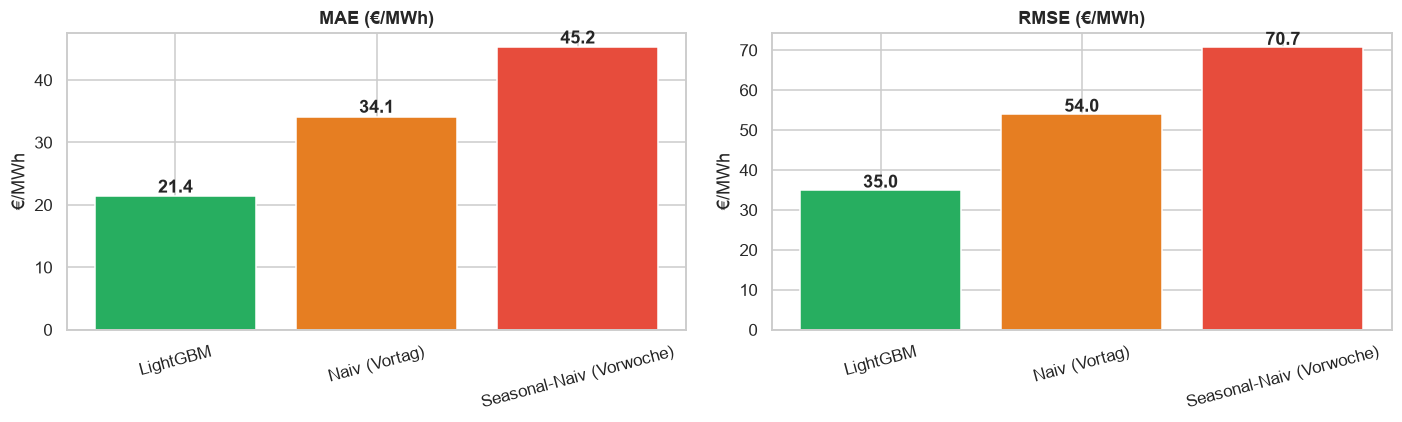

LightGBM verbessert die Seasonal-Naive-Baseline um 52.8 % (MAE).


In [5]:
tbl = (metrics.set_index("model")
       .loc[["lightgbm", "naive", "seasonal_naive"], ["MAE", "RMSE", "MAE_vs_seasonal_%"]]
       .rename(index={"lightgbm": "LightGBM", "naive": "Naiv (Vortag)",
                      "seasonal_naive": "Seasonal-Naiv (Vorwoche)"}))
display(tbl.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "MAE_vs_seasonal_%": "{:+.1f}%"})
        .set_caption("Rolling-origin-Backtest — €/MWh, out-of-sample 2022–2026"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = [C_LGBM, C_NAIVE, C_SEAS]
for ax, col, ttl in zip(axes, ["MAE", "RMSE"], ["MAE (€/MWh)", "RMSE (€/MWh)"]):
    ax.bar(tbl.index, tbl[col], color=colors)
    for i, v in enumerate(tbl[col]):
        ax.text(i, v + 0.6, f"{v:.1f}", ha="center", fontweight="bold")
    ax.set(title=ttl, ylabel="€/MWh"); ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.show()

imp = tbl.loc["LightGBM", "MAE_vs_seasonal_%"]
print(f"LightGBM verbessert die Seasonal-Naive-Baseline um {imp:.1f} % (MAE).")

## 5 · Der Härtefall: die Dunkelflaute im Dezember 2024

Das Fenster um den **höchsten Preis des gesamten Backtests** (12.12.2024, ~936 €/MWh): eine
**Dunkelflaute** — wenig Wind, kaum PV, hohe Residuallast, teure Gaskraftwerke am Grenzpreis.
Genau hier trennt sich das Modell von der Baseline: LightGBM *sieht* die Knappheit über die
Fundamental-Prognosen (Residuallast) kommen, während die Seasonal-Naive stur die Vorwoche
wiederholt und den Sprung komplett verpasst.

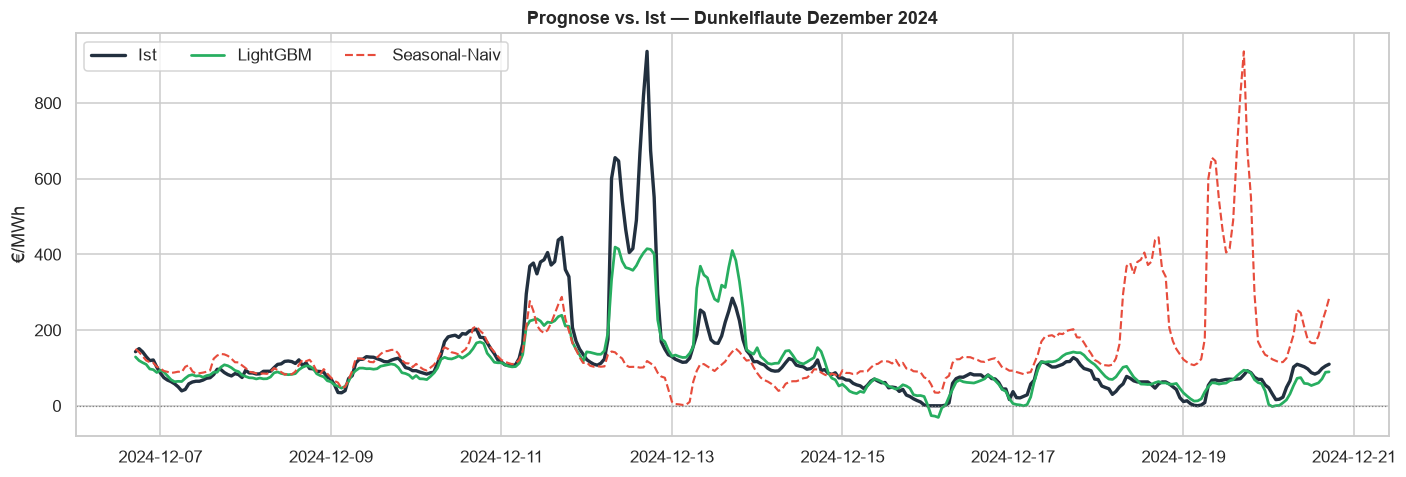

MAE in diesem Fenster:  LightGBM 34.9  vs.  Seasonal-Naiv 98.0 €/MWh


In [6]:
peak = preds["y_true"].idxmax()
win = preds.loc[peak - pd.Timedelta(days=6): peak + pd.Timedelta(days=8)].copy()
win.index = win.index.tz_localize(None)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(win.index, win["y_true"], color=C_TRUTH, lw=2.2, label="Ist")
ax.plot(win.index, win["lightgbm"], color=C_LGBM, lw=1.8, label="LightGBM")
ax.plot(win.index, win["seasonal_naive"], color=C_SEAS, lw=1.4, ls="--", label="Seasonal-Naiv")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set(title="Prognose vs. Ist — Dunkelflaute Dezember 2024", ylabel="€/MWh", xlabel="")
ax.legend(ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

mae_lgbm = (win["lightgbm"] - win["y_true"]).abs().mean()
mae_seas = (win["seasonal_naive"] - win["y_true"]).abs().mean()
print(f"MAE in diesem Fenster:  LightGBM {mae_lgbm:.1f}  vs.  Seasonal-Naiv {mae_seas:.1f} €/MWh")

## 6 · Fehler nach Regime — die ehrliche Jahres-Aufschlüsselung

Ein aggregierter MAE kann ein gutes Krisenjahr hinter vielen ruhigen verstecken. Der
rolling-origin-Backtest erlaubt die **Aufschlüsselung pro Kalenderjahr** — und die Geschichte ist
sauber: LightGBM schlägt beide Baselines in **jedem** Jahr, am deutlichsten im Volatilitätsjahr
**2022** (MAE 38,5 vs. 86,9 der Seasonal-Naive).

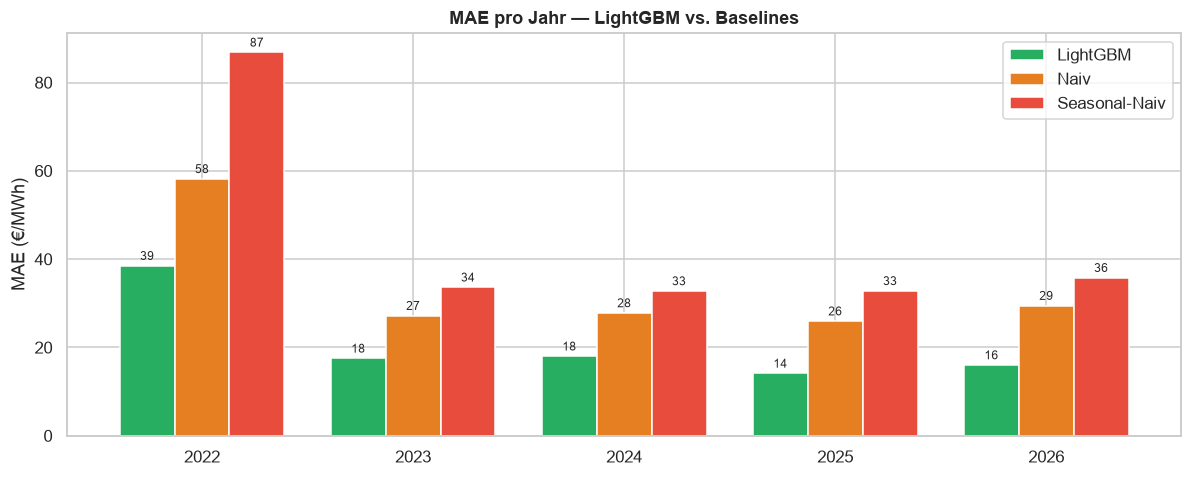

,year,n,MAE_lightgbm,MAE_naive,MAE_seasonal_naive,Verbesserung_pct
0,2022,8592,38.53,58.20,86.85,55.6
1,2023,8760,17.54,27.21,33.64,47.9
2,2024,8784,18.02,27.82,32.80,45.1
3,2025,8760,14.14,25.97,32.83,56.9
4,2026,3984,16.03,29.49,35.80,55.2


In [7]:
r = (regime.set_index("year")[["MAE_lightgbm", "MAE_naive", "MAE_seasonal_naive"]]
     .rename(columns={"MAE_lightgbm": "LightGBM", "MAE_naive": "Naiv",
                      "MAE_seasonal_naive": "Seasonal-Naiv"}))

ax = r.plot.bar(figsize=(11, 4.5), color=[C_LGBM, C_NAIVE, C_SEAS], width=0.78)
ax.set(title="MAE pro Jahr — LightGBM vs. Baselines", ylabel="MAE (€/MWh)", xlabel="")
ax.tick_params(axis="x", labelrotation=0)
ax.legend(title="")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

display(regime.assign(Verbesserung_pct=(100 * (1 - regime["MAE_lightgbm"]
        / regime["MAE_seasonal_naive"])).round(1)))

## 7 · Was das Modell nutzt — Feature-Importances

Gain-basierte Wichtigkeit (Beitrag zur Fehlerreduktion), nach Feature-Gruppe eingefärbt. Das Bild
bestätigt die Ökonomie aus der EDA:

- Die **Residuallast-Prognose dominiert** — allein rund **56 %** der Gain (die Fundamental-Gruppe
  zusammen ~69 %) und damit der mit Abstand stärkste Einzeltreiber. Das *ist* die Merit-Order: die
  Last, die konventionelle (teure) Kraftwerke decken müssen, setzt den Grenzpreis.
- Die **Preishistorie** ist der zweite Pfeiler (~27 %, breit über Lags und Vortags-Aggregate
  gestreut): sie kodiert das **Niveau/Regime** — der bewusste Proxy fürs Brennstoffkosten-Niveau
  statt teurer Gas-/CO₂-Serien. (Nach *Split*-Häufigkeit läge sie sogar vorn — viele Features, oft
  genutzt; per Gain zählt aber, wie stark ein Split den Fehler senkt.)
- **Kalender** trägt den Rest (~4 %): Feinschliff bei Tages-/Wochenmustern, die in den
  Fundamentaldaten noch nicht stecken.

> **Getrennt von der Bewertung.** Dieses Fit dient nur der *Interpretation der Treiber*. Es läuft
> auf dem jüngsten 2-Jahres-Fenster; die Leistungszahlen oben stammen ausschließlich aus dem
> leckagefreien rolling-origin-Backtest.

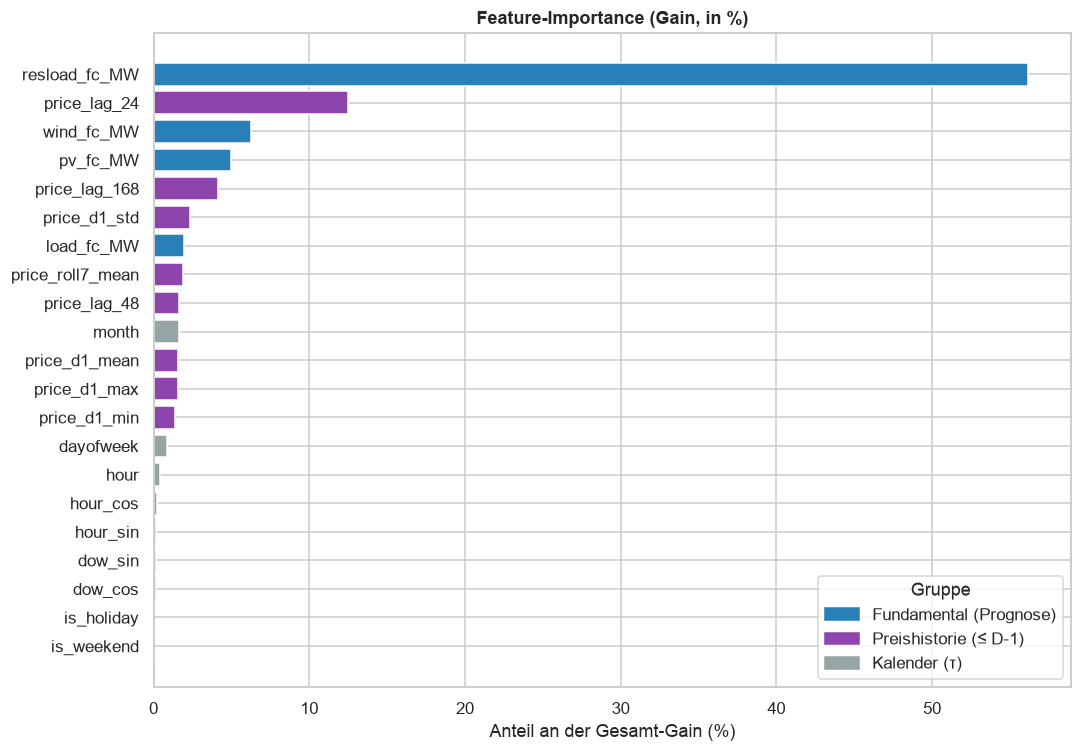

Gain-Anteil je Gruppe (%):
  Fundamental (Prognose)    69.4 %
  Preishistorie (≤ D-1)     27.0 %
  Kalender (τ)               3.6 %


In [8]:
window = X.index >= X.index.max() - pd.Timedelta(hours=config.TRAIN_WINDOW_HOURS)
fitted = model.train_lgbm(X[window], y[window])
gain = fitted.booster_.feature_importance(importance_type="gain")
imp = (pd.Series(gain, index=X.columns) / gain.sum() * 100).sort_values()

col_of = {}
for gname, cols in groups.items():
    for c in cols:
        col_of[c] = gname
palette = {"Fundamental (Prognose)": "#2980b9", "Preishistorie (≤ D-1)": "#8e44ad",
           "Kalender (τ)": "#95a5a6"}
bar_colors = [palette[col_of[c]] for c in imp.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp.index, imp.values, color=bar_colors)
ax.set(title="Feature-Importance (Gain, in %)", xlabel="Anteil an der Gesamt-Gain (%)")
ax.legend(handles=[mpatches.Patch(color=c, label=g) for g, c in palette.items()],
          loc="lower right", title="Gruppe")
plt.tight_layout(); plt.show()

by_group = imp.groupby(col_of).sum().reindex(palette).round(1)
print("Gain-Anteil je Gruppe (%):")
for g, v in by_group.items():
    print(f"  {g:24s} {v:5.1f} %")

## 8 · Entscheidungs-Lens: Negativpreise treffen

Negativpreise sind **handlungsrelevant** (Speicher laden, flexible Lasten hochfahren) und die
schwersten Fälle. Statt sie im MAE zu verstecken, bewerten wir sie als **Klassifikation**: Wie gut
markiert das Modell (Prognose ≤ 0) die tatsächlich negativen Stunden? Kein zweites Modell — dieselben
Prognosen, nur durch eine Entscheidungsbrille gelesen.

Tatsächlich negative Stunden: 1,869  (4.8 % der Backtest-Stunden)
Precision: 79 %   (von den als negativ prognostizierten Stunden waren so viele wirklich negativ)
Recall:    61 %   (so viele der echten Negativstunden hat das Modell erwischt)


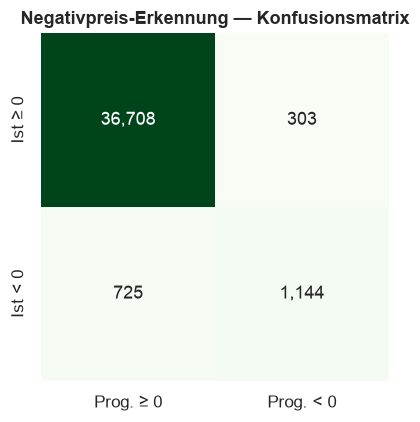

In [9]:
p = preds.dropna(subset=["y_true", "lightgbm"])
actual_neg = p["y_true"] <= 0
pred_neg = p["lightgbm"] <= 0
tp = int((actual_neg & pred_neg).sum()); fp = int((~actual_neg & pred_neg).sum())
fn = int((actual_neg & ~pred_neg).sum()); tn = int((~actual_neg & ~pred_neg).sum())
precision = tp / (tp + fp); recall = tp / (tp + fn)

print(f"Tatsächlich negative Stunden: {int(actual_neg.sum()):,}  ({actual_neg.mean()*100:.1f} % der Backtest-Stunden)")
print(f"Precision: {precision*100:.0f} %   (von den als negativ prognostizierten Stunden waren so viele wirklich negativ)")
print(f"Recall:    {recall*100:.0f} %   (so viele der echten Negativstunden hat das Modell erwischt)")

cm = pd.DataFrame([[tn, fp], [fn, tp]],
                  index=["Ist ≥ 0", "Ist < 0"], columns=["Prog. ≥ 0", "Prog. < 0"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, square=True, ax=ax)
ax.set(title="Negativpreis-Erkennung — Konfusionsmatrix")
plt.tight_layout(); plt.show()

## 9 · Fehleranalyse — wo das Modell (systematisch) danebenliegt

Kein Modell ist neutral in den Rändern. Zwei Blicke machen das Verhalten transparent:

- **Prognose vs. Ist** (links): An den Extremen zieht sich die Wolke *zur Mitte* — das Modell
  **glättet** (Regression zur Mitte): Preisspitzen werden tendenziell **unterschätzt**,
  Negativpreis-Tiefs leicht **überschätzt**.
- **Bias nach Preisniveau** (rechts): der mittlere Fehler (Prognose − Ist) je Preis-Dezil macht
  diese Verzerrung quantitativ sichtbar — nahe null im normalen Bereich, negativ (Unterschätzung)
  im teuersten Dezil. Ehrlich benannt statt weggeglättet.

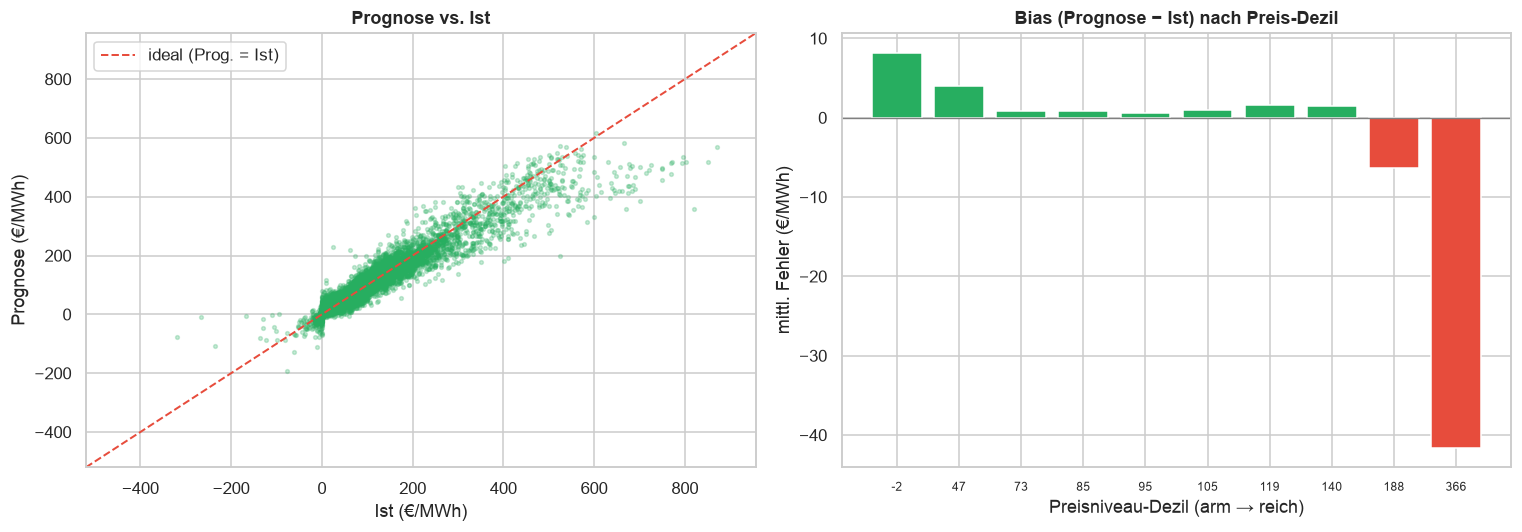

Extrembeispiel 2024-12-12 17h:  Ist 936  →  Prognose 415 €/MWh  (Spitze gedämpft, wie erwartet)


In [10]:
p = preds.dropna(subset=["y_true", "lightgbm"]).copy()
p["err"] = p["lightgbm"] - p["y_true"]   # Prognose − Ist; < 0 = Unterschätzung

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

samp = p.sample(min(9000, len(p)), random_state=config.SEED)
lim = [p["y_true"].min() - 20, p["y_true"].max() + 20]
axes[0].scatter(samp["y_true"], samp["lightgbm"], s=6, alpha=0.25, color=C_LGBM)
axes[0].plot(lim, lim, color=C_SEAS, lw=1.3, ls="--", label="ideal (Prog. = Ist)")
axes[0].set(title="Prognose vs. Ist", xlabel="Ist (€/MWh)", ylabel="Prognose (€/MWh)",
            xlim=lim, ylim=lim)
axes[0].legend(loc="upper left")

p["dez"] = pd.qcut(p["y_true"], 10, duplicates="drop")
g = p.groupby("dez", observed=True)
centers = g["y_true"].mean().values
bias = g["err"].mean().values
axes[1].axhline(0, color="grey", lw=0.9)
axes[1].bar(range(len(bias)), bias, color=[C_SEAS if b < 0 else C_LGBM for b in bias])
axes[1].set(title="Bias (Prognose − Ist) nach Preis-Dezil", ylabel="mittl. Fehler (€/MWh)",
            xlabel="Preisniveau-Dezil (arm → reich)")
axes[1].set_xticks(range(len(centers)))
axes[1].set_xticklabels([f"{c:.0f}" for c in centers], rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

top = p.nlargest(1, "y_true").index[0]
print(f"Extrembeispiel {top:%Y-%m-%d %H}h:  Ist {p.loc[top,'y_true']:.0f}  →  "
      f"Prognose {p.loc[top,'lightgbm']:.0f} €/MWh  (Spitze gedämpft, wie erwartet)")

## 10 · Fazit

- **LightGBM schlägt die Baseline klar und stabil:** MAE **21,4** vs. **45,2 €/MWh** (**−52,8 %**),
  in *jedem* Backtest-Jahr — nicht nur im Mittel.
- **Der Vorsprung kommt aus der Ökonomie, nicht aus Tuning:** die Residuallast-Prognose trägt die
  Merit-Order (allein ~56 % der Gain), die Preishistorie das Regime-Niveau — beides leckagefrei zum
  Gate Closure.
- **Ehrlich bewertet:** rolling-origin statt Zufalls-Split, Metriken pro Regime, Negativpreise als
  eigene Entscheidungs-Lens (Recall 61 % @ Precision 79 %), und eine offen benannte Schwäche —
  die **Dämpfung der Extreme**.

**Grenzen & Ausblick.** Das Modell glättet Spitzen; genau dort läge der nächste Gewinn.
Aufbaustufen (siehe `PLAN.md`): **A** — eine Spike-/Negativpreis-**Klassifikation** auf denselben
Features; **B** — regionale Nord-Süd-Engpässe (Redispatch-Warnung). Fundamental fehlen als
bewusste, token-freie Auslassung die **Gas-/CO₂-Preise** — aktuell über die Preis-Lags proxyiert.